In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import rasterio
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rasterio"])
    import rasterio

print("Librerías listas.")

Mounted at /content/drive
Librerías listas.


In [ ]:
BASE_DRIVE = "/content/drive/MyDrive"

# Carpeta donde quedaron los mapas generados por el notebook anterior.
TIFF_DIR = os.path.join(BASE_DRIVE, "MAPAS_SUSCEPTIBILIDAD_MODELOS")

# Carpeta para guardar las gráficas y tablas de distribución.
OUTPUT_DIR = os.path.join(TIFF_DIR, "DISTRIBUCION_PIXELES")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Si existe el resumen del notebook anterior, se usará para ubicar los raster de probabilidad.
SUMMARY_CSV = os.path.join(TIFF_DIR, "resumen_mejores_configuraciones.csv")
USE_SUMMARY_CSV_IF_EXISTS = True

# Modelos que quieres graficar y orden preferido.
# Deja la lista vacía [] para graficar todos los TIFF de probabilidad encontrados.
MODELOS_A_GRAFICAR = [
    "GeoFormer",
    "TabTransformer",
    "FT-Transformer",
    "CatBoost_native_categorical",
]

# Valores NoData que se eliminarán si aparecen en los TIFF.
NODATA_EXTRA = [-99999, -9999, -32768, 32767]

N_BINS = 100

SMOOTH_WINDOW = 9

print("Carpeta de TIFF:", TIFF_DIR)
print("Carpeta de salida:", OUTPUT_DIR)

def nombre_para_grafico(modelo):
    modelo_str = str(modelo).lower()

    if modelo_str.startswith("mlp"):
        return "MLP"

    if modelo_str.startswith("catboost"):
        return "CatBoost"

    if modelo_str.startswith("random_forest") or modelo_str.startswith("random forest"):
        return "Random forest"

    return modelo

Carpeta de TIFF: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS
Carpeta de salida: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/DISTRIBUCION_PIXELES


In [ ]:
def limpiar_nombre_modelo(path):
    # Convierte nombres como GeoFormer_probabilidad.tif en GeoFormer.
    name = Path(path).stem
    name = name.replace("_probabilidad", "")
    name = name.replace("_prob", "")
    return name


def normalizar_nombre(name):
    return str(name).lower().replace("-", "_").replace(" ", "_")


def buscar_tiffs_probabilidad(tiff_dir, summary_csv=None, use_summary=True):
    tiff_paths = {}

    if use_summary and summary_csv and os.path.exists(summary_csv):
        df_summary = pd.read_csv(summary_csv)
        if {"model", "prob_raster"}.issubset(df_summary.columns):
            for _, row in df_summary.iterrows():
                model = str(row["model"])
                path = str(row["prob_raster"])
                if os.path.exists(path):
                    tiff_paths[model] = path

    if len(tiff_paths) == 0:
        candidates = sorted(Path(tiff_dir).rglob("*probabilidad*.tif"))
        for p in candidates:
            name = p.name.lower()
            if "clase" in name or "threshold" in name or "thr" in name:
                continue
            model = limpiar_nombre_modelo(p)
            tiff_paths[model] = str(p)

    return tiff_paths


tiff_paths = buscar_tiffs_probabilidad(
    TIFF_DIR,
    summary_csv=SUMMARY_CSV,
    use_summary=USE_SUMMARY_CSV_IF_EXISTS
)

if len(tiff_paths) == 0:
    print("No se encontraron TIFF de probabilidad.")
    print("Revisa TIFF_DIR o verifica que los archivos terminen en *_probabilidad.tif")
else:
    print("TIFF encontrados:")
    for model, path in tiff_paths.items():
        print(f" - {model}: {path}")


# Filtrar y ordenar modelos si MODELOS_A_GRAFICAR no está vacío.
if len(MODELOS_A_GRAFICAR) > 0:
    normalized_available = {normalizar_nombre(k): k for k in tiff_paths.keys()}
    tiff_paths_filtrados = {}

    for desired in MODELOS_A_GRAFICAR:
        key = normalizar_nombre(desired)
        if key in normalized_available:
            real_name = normalized_available[key]
            tiff_paths_filtrados[desired] = tiff_paths[real_name]
        else:
            print(f"Advertencia: no encontré TIFF para {desired}")

    tiff_paths = tiff_paths_filtrados

if len(tiff_paths) == 0:
    raise FileNotFoundError("No hay TIFF válidos para graficar.")

print("\nModelos que se van a graficar:")
for model in tiff_paths:
    print(" -", model)

TIFF encontrados:
 - GeoFormer: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/GeoFormer_probabilidad.tif
 - MLP_one_hot: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/MLP_one_hot_probabilidad.tif
 - CatBoost_native_categorical: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/CatBoost_native_categorical_probabilidad.tif
 - Random_Forest_target: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/Random_Forest_target_probabilidad.tif
 - TabTransformer: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/TabTransformer_probabilidad.tif
 - FT-Transformer: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/FT_Transformer_probabilidad.tif

Modelos que se van a graficar:
 - GeoFormer
 - TabTransformer
 - FT-Transformer
 - CatBoost_native_categorical


In [ ]:
def leer_pixeles_validos(tif_path, nodata_extra=None):
    nodata_extra = nodata_extra or []

    with rasterio.open(tif_path) as src:
        arr = src.read(1).astype("float64")
        nodata = src.nodata
        shape = arr.shape
        crs = src.crs
        transform = src.transform

    valid = np.isfinite(arr)

    if nodata is not None:
        valid &= arr != nodata

    for nd in nodata_extra:
        valid &= arr != nd

    # En este caso son mapas de probabilidad, por eso se filtra 0 a 1.
    valid &= (arr >= 0) & (arr <= 1)

    values = arr[valid].astype("float32")

    info = {
        "shape": shape,
        "crs": str(crs),
        "n_total_pixeles": int(arr.size),
        "n_validos": int(values.size),
        "n_invalidos": int(arr.size - values.size),
        "porcentaje_valido": float(values.size / arr.size * 100) if arr.size > 0 else np.nan,
    }

    return values, info


def calcular_estadisticas(values):
    return {
        "min": float(np.min(values)),
        "p05": float(np.quantile(values, 0.05)),
        "p25": float(np.quantile(values, 0.25)),
        "media": float(np.mean(values)),
        "mediana": float(np.median(values)),
        "p75": float(np.quantile(values, 0.75)),
        "p95": float(np.quantile(values, 0.95)),
        "max": float(np.max(values)),
    }


stats_rows = []
hist_rows = []
range_rows = []

bins = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

rangos = [
    (0.0, 0.2, "0.0-0.2 muy baja"),
    (0.2, 0.4, "0.2-0.4 baja"),
    (0.4, 0.6, "0.4-0.6 media"),
    (0.6, 0.8, "0.6-0.8 alta"),
    (0.8, 1.0, "0.8-1.0 muy alta"),
]

for modelo, tif_path in tiff_paths.items():
    values, info = leer_pixeles_validos(tif_path, nodata_extra=NODATA_EXTRA)

    if values.size == 0:
        print(f"{modelo}: no tiene pixeles válidos entre 0 y 1.")
        continue

    stats = calcular_estadisticas(values)
    row = {
        "modelo": modelo,
        "tif": tif_path,
        **info,
        **stats,
    }
    stats_rows.append(row)

    counts, edges = np.histogram(values, bins=bins)
    total = counts.sum()

    for center, left, right, count in zip(bin_centers, edges[:-1], edges[1:], counts):
        hist_rows.append({
            "modelo": modelo,
            "bin_left": left,
            "bin_right": right,
            "bin_center": center,
            "conteo_pixeles": int(count),
            "porcentaje_pixeles": float(count / total * 100) if total > 0 else np.nan,
        })

    for left, right, label in rangos:
        if right < 1.0:
            mask = (values >= left) & (values < right)
        else:
            mask = (values >= left) & (values <= right)

        count = int(mask.sum())
        range_rows.append({
            "modelo": modelo,
            "rango": label,
            "conteo_pixeles": count,
            "porcentaje_pixeles": float(count / values.size * 100),
        })

stats_df = pd.DataFrame(stats_rows)
hist_df = pd.DataFrame(hist_rows)
range_df = pd.DataFrame(range_rows)

stats_path = os.path.join(OUTPUT_DIR, "estadisticas_pixeles_probabilidad.csv")
hist_path = os.path.join(OUTPUT_DIR, "histograma_pixeles_probabilidad.csv")
range_path = os.path.join(OUTPUT_DIR, "conteo_por_rangos_probabilidad.csv")

stats_df.to_csv(stats_path, index=False, encoding="utf-8-sig")
hist_df.to_csv(hist_path, index=False, encoding="utf-8-sig")
range_df.to_csv(range_path, index=False, encoding="utf-8-sig")

display(stats_df)
print("Estadísticas guardadas en:", stats_path)
print("Histograma guardado en:", hist_path)
print("Conteo por rangos guardado en:", range_path)

,modelo,tif,shape,crs,n_total_pixeles,n_validos,n_invalidos,porcentaje_valido,min,p05,p25,media,mediana,p75,p95,max
0,GeoFormer,/content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_M...,"(2255, 3440)",EPSG:3115,7757200,3049057,4708143,39.306154,0.065008,0.084360,0.121229,0.557900,0.563789,0.986253,0.996114,0.998100
1,TabTransformer,/content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_M...,"(2255, 3440)",EPSG:3115,7757200,3049057,4708143,39.306154,0.017037,0.026130,0.068286,0.527811,0.558923,0.961748,0.978387,0.983518
2,FT-Transformer,/content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_M...,"(2255, 3440)",EPSG:3115,7757200,3049057,4708143,39.306154,0.117467,0.120052,0.136091,0.508990,0.398811,0.956919,0.958487,0.959573
3,CatBoost_native_categorical,/content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_M...,"(2255, 3440)",EPSG:3115,7757200,3049057,4708143,39.306154,0.026571,0.036083,0.128128,0.526105,0.528579,0.928075,0.984323,0.989811


Estadísticas guardadas en: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/DISTRIBUCION_PIXELES/estadisticas_pixeles_probabilidad.csv
Histograma guardado en: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/DISTRIBUCION_PIXELES/histograma_pixeles_probabilidad.csv
Conteo por rangos guardado en: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/DISTRIBUCION_PIXELES/conteo_por_rangos_probabilidad.csv


In [ ]:
range_pivot_count = range_df.pivot(index="modelo", columns="rango", values="conteo_pixeles")
range_pivot_percent = range_df.pivot(index="modelo", columns="rango", values="porcentaje_pixeles")

print("Conteo de pixeles por rango:")
display(range_pivot_count)

print("Porcentaje de pixeles por rango:")
display(range_pivot_percent.round(2))

Conteo de pixeles por rango:


rango,0.0-0.2 muy baja,0.2-0.4 baja,0.4-0.6 media,0.6-0.8 alta,0.8-1.0 muy alta
modelo,,,,,
CatBoost_native_categorical,961395,331443,355399,259894,1140926
FT-Transformer,1154899,371264,208165,225127,1089602
GeoFormer,1097266,302642,152641,145717,1350791
TabTransformer,1152464,251743,146207,142769,1355874


Porcentaje de pixeles por rango:


rango,0.0-0.2 muy baja,0.2-0.4 baja,0.4-0.6 media,0.6-0.8 alta,0.8-1.0 muy alta
modelo,,,,,
CatBoost_native_categorical,31.53,10.87,11.66,8.52,37.42
FT-Transformer,37.88,12.18,6.83,7.38,35.74
GeoFormer,35.99,9.93,5.01,4.78,44.30
TabTransformer,37.80,8.26,4.80,4.68,44.47


GeoFormer - suma frecuencia relativa sin suavizar: 1.000000
GeoFormer - suma frecuencia relativa suavizada: 1.000000
TabTransformer - suma frecuencia relativa sin suavizar: 1.000000
TabTransformer - suma frecuencia relativa suavizada: 1.000000
FT-Transformer - suma frecuencia relativa sin suavizar: 1.000000
FT-Transformer - suma frecuencia relativa suavizada: 1.000000
CatBoost - suma frecuencia relativa sin suavizar: 1.000000
CatBoost - suma frecuencia relativa suavizada: 1.000000


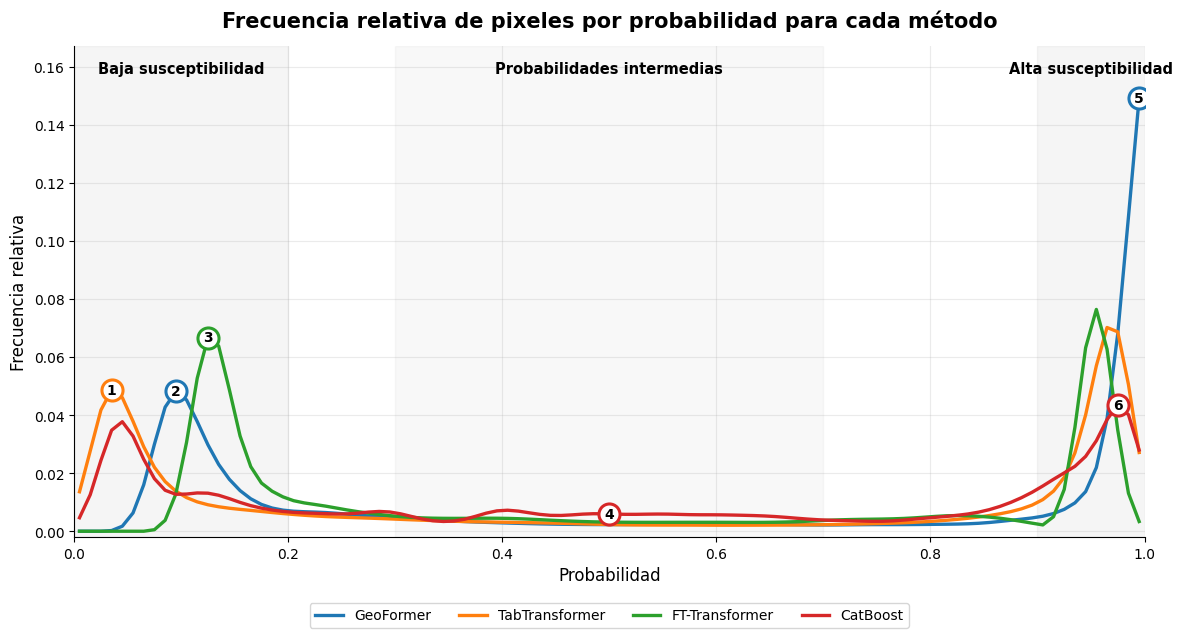

Figura guardada en: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/DISTRIBUCION_PIXELES/frecuencia_relativa_pixeles_probabilidad_anotada_limpia.png
SVG guardado en: /content/drive/MyDrive/MAPAS_SUSCEPTIBILIDAD_MODELOS/DISTRIBUCION_PIXELES/frecuencia_relativa_pixeles_probabilidad_anotada_limpia.svg


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt


def suavizar_y_preservando_masa(y, window=9):
    """
    Suaviza la curva, pero conserva la suma total de la frecuencia relativa.
    Es decir, si y suma 1 antes del suavizado, también suma 1 después.
    """
    y = np.asarray(y, dtype=float)

    if window is None or window <= 1:
        return y

    if window % 2 == 0:
        window += 1

    xk = np.linspace(-2.5, 2.5, window)
    kernel = np.exp(-0.5 * xk**2)
    kernel = kernel / kernel.sum()

    pad = window // 2
    y_pad = np.pad(y, pad_width=pad, mode="edge")

    y_smooth = np.convolve(y_pad, kernel, mode="valid")

    if y_smooth.sum() > 0:
        y_smooth = y_smooth / y_smooth.sum() * y.sum()

    return y_smooth


# FIGURA LIMPIA Y ELEGANTE - FRECUENCIA RELATIVA REAL

fig, ax = plt.subplots(figsize=(12, 6.5))

curve_data = {}


for modelo in tiff_paths.keys():
    df_m = hist_df[hist_df["modelo"] == modelo].sort_values("bin_center").copy()

    x = df_m["bin_center"].values

    # conteo del bin / total de pixeles válidos del modelo
    # La suma de y para cada modelo debe ser 1.
    counts = df_m["conteo_pixeles"].values.astype(float)
    total = counts.sum()

    if total == 0:
        continue

    y = counts / total

    print(f"{nombre_para_grafico(modelo)} - suma frecuencia relativa sin suavizar: {y.sum():.6f}")

    y_smooth = suavizar_y_preservando_masa(y, window=SMOOTH_WINDOW)

    print(f"{nombre_para_grafico(modelo)} - suma frecuencia relativa suavizada: {y_smooth.sum():.6f}")

    label = nombre_para_grafico(modelo)

    line, = ax.plot(
        x,
        y_smooth,
        linewidth=2.4,
        label=label
    )

    curve_data[label] = {
        "x": x,
        "y": y_smooth,
        "color": line.get_color()
    }


ax.axvspan(0.00, 0.20, alpha=0.08, color="gray")
ax.axvspan(0.30, 0.70, alpha=0.05, color="gray")
ax.axvspan(0.90, 1.00, alpha=0.08, color="gray")

ax.text(
    0.10, 0.97,
    "Baja susceptibilidad",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10.5,
    fontweight="bold"
)

ax.text(
    0.50, 0.97,
    "Probabilidades intermedias",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10.5,
    fontweight="bold"
)

ax.text(
    0.95, 0.97,
    "Alta susceptibilidad",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=10.5,
    fontweight="bold"
)


def buscar_pico(label, xmin, xmax):
    x = curve_data[label]["x"]
    y = curve_data[label]["y"]

    mask = (x >= xmin) & (x <= xmax)

    if not np.any(mask):
        return None

    x_sel = x[mask]
    y_sel = y[mask]

    idx = np.argmax(y_sel)

    return float(x_sel[idx]), float(y_sel[idx]), curve_data[label]["color"]


def buscar_valor(label, x_obj):
    x = curve_data[label]["x"]
    y = curve_data[label]["y"]

    y_obj = float(np.interp(x_obj, x, y))

    return float(x_obj), y_obj, curve_data[label]["color"]


def marcar_numero(numero, x, y, color):
    ax.scatter(
        x,
        y,
        s=230,
        facecolor="white",
        edgecolor=color,
        linewidth=2.2,
        zorder=10
    )

    ax.text(
        x,
        y,
        str(numero),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="black",
        zorder=11
    )


puntos = []

# 1. TabTransformer: pico en baja probabilidad
if "TabTransformer" in curve_data:
    punto = buscar_pico("TabTransformer", 0.00, 0.08)
    if punto is not None:
        puntos.append((1, *punto))

# 2. GeoFormer: pico en baja probabilidad
if "GeoFormer" in curve_data:
    punto = buscar_pico("GeoFormer", 0.06, 0.14)
    if punto is not None:
        puntos.append((2, *punto))

if "FT-Transformer" in curve_data:
    punto = buscar_pico("FT-Transformer", 0.10, 0.17)
    if punto is not None:
        puntos.append((3, *punto))

if "CatBoost" in curve_data:
    punto = buscar_valor("CatBoost", 0.50)
    if punto is not None:
        puntos.append((4, *punto))

candidatos_altos = []

for label in ["GeoFormer", "TabTransformer", "FT-Transformer"]:
    if label in curve_data:
        punto = buscar_pico(label, 0.90, 1.00)
        if punto is not None:
            candidatos_altos.append(punto)

if candidatos_altos:
    x_p, y_p, color_p = max(candidatos_altos, key=lambda t: t[1])
    puntos.append((5, x_p, y_p, color_p))

# 6. CatBoost en probabilidades altas
if "CatBoost" in curve_data:
    punto = buscar_pico("CatBoost", 0.90, 1.00)
    if punto is not None:
        puntos.append((6, *punto))

for numero, x, y, color in puntos:
    marcar_numero(numero, x, y, color)

# CONFIGURACIÓN GENERAL

ax.set_title(
    "Frecuencia relativa de pixeles por probabilidad para cada método",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Probabilidad", fontsize=12)
ax.set_ylabel("Frecuencia relativa", fontsize=12)

ax.set_xlim(0, 1)

ymax = max([np.nanmax(v["y"]) for v in curve_data.values()])
ax.set_ylim(-0.002, ymax + ymax * 0.12)

ax.grid(True, alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=True,
    fontsize=10
)

plt.tight_layout()

# GUARDAR FIGURA

fig_path = os.path.join(
    OUTPUT_DIR,
    "frecuencia_relativa_pixeles_probabilidad_anotada_limpia.png"
)

fig_path_svg = fig_path.replace(".png", ".svg")

plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_svg, format="svg", bbox_inches="tight")

plt.show()

print("Figura guardada en:", fig_path)
print("SVG guardado en:", fig_path_svg)

In [ ]:
plt.figure(figsize=(10, 6))

for modelo in tiff_paths.keys():
    df_m = hist_df[hist_df["modelo"] == modelo].sort_values("bin_center")
    x = df_m["bin_center"].values
    y = df_m["conteo_pixeles"].values
    y_smooth = suavizar_y(y, window=SMOOTH_WINDOW)

    plt.plot(x, y_smooth, linewidth=2, label=nombre_para_grafico(modelo))

plt.xlabel("Probabilidad")
plt.ylabel("Número de pixeles")
plt.title("Conteo de pixeles por probabilidad para cada método")
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "distribucion_conteo_pixeles_probabilidad.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada en:", fig_path)

In [ ]:
plt.figure(figsize=(10, 6))

for modelo in tiff_paths.keys():
    df_m = hist_df[hist_df["modelo"] == modelo].sort_values("bin_center").copy()
    df_m["cdf"] = df_m["conteo_pixeles"].cumsum() / df_m["conteo_pixeles"].sum() * 100

    plt.plot(df_m["bin_center"], df_m["cdf"], linewidth=2, label=nombre_para_grafico(modelo))

plt.xlabel("Probabilidad")
plt.ylabel("Pixeles acumulados (%)")
plt.title("Distribución acumulada de pixeles por método")
plt.xlim(0, 1)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "distribucion_acumulada_pixeles_probabilidad.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada en:", fig_path)

In [ ]:
excel_path = os.path.join(OUTPUT_DIR, "distribucion_pixeles_probabilidad_modelos.xlsx")

with pd.ExcelWriter(excel_path) as writer:
    stats_df.to_excel(writer, sheet_name="estadisticas", index=False)
    hist_df.to_excel(writer, sheet_name="histograma", index=False)
    range_df.to_excel(writer, sheet_name="rangos", index=False)
    range_pivot_count.to_excel(writer, sheet_name="rangos_conteo")
    range_pivot_percent.to_excel(writer, sheet_name="rangos_porcentaje")

print("Excel guardado en:", excel_path)